# SVM Model — Binary Encoding Pipeline
**Assigned pipeline: Binary Encoding → Support Vector Machine (SVM)**

Course: IT2011 — Artificial Intelligence and Machine Learning (SLIIT, Year 2, Semester 1)

## 1. Introduction

**Problem:** binary classification of mushrooms as **edible** (`class = 0`) or **poisonous**
(`class = 1`), using the 21 categorical physical/environmental features in the UCI Mushroom
dataset (`cap-shape`, `odor`, `gill-color`, `habitat`, etc., with `veil-type` already dropped
during preprocessing since it has only one unique value).

**Why SVM is a suitable model here:**
- It works well on the **compact 0/1 bit-columns** produced by **Binary Encoding**. Binary Encoding
  writes each category's integer code in binary, so a feature with *n* categories needs only
  `ceil(log2(n))` columns instead of the *n - 1* columns of one-hot. This gives a much smaller
  feature space than one-hot while avoiding the false ordering of plain label encoding, which a
  distance/dot-product based model like SVM would wrongly treat as real magnitude.
- It finds a **maximum-margin** decision boundary, which is robust, and its kernels
  (linear / RBF / polynomial / sigmoid) let us test whether the data is linearly or
  non-linearly separable.
- The dataset is small (about 8k rows), so SVM training time is not a problem.

## 2. Load the Preprocessed Data

Loads `step_M4_binary_encoded.csv`, the output of `IT0004_BinaryEncoding.ipynb` (mode imputation of
`stalk-root`, `veil-type` dropped, all feature columns Binary-Encoded, target `class`: 0 = edible,
1 = poisonous). This is the only preprocessing output used for this model, per the assigned
Binary Encoding → SVM pipeline.

If the CSV does not exist yet, the cell below rebuilds it with exactly the same steps as
`IT0004_BinaryEncoding.ipynb` (and saves it), so this notebook can always run.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Folder layout: notebooks/ (this file), results/outputs/, results/eda_visualizations/, data/raw/
BASE = '..' if os.path.isdir('../results') else '.'
OUT = f'{BASE}/results/outputs'
VIZ = f'{BASE}/results/eda_visualizations'
os.makedirs(OUT, exist_ok=True)
os.makedirs(VIZ, exist_ok=True)

CSV = f'{OUT}/step_M4_binary_encoded.csv'
RAW = f'{BASE}/data/raw/mushrooms.csv'
UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
FEATURES = ['cap-shape','cap-surface','cap-color','bruises','odor','gill-attachment','gill-spacing',
            'gill-size','gill-color','stalk-shape','stalk-root','stalk-surface-above-ring',
            'stalk-surface-below-ring','stalk-color-above-ring','stalk-color-below-ring','veil-type',
            'veil-color','ring-number','ring-type','spore-print-color','population','habitat']

if os.path.exists(CSV):
    df = pd.read_csv(CSV)
    print('Loaded', CSV)
else:
    print(CSV, 'not found -> rebuilding it with the same steps as IT0004_BinaryEncoding.ipynb')
    try:
        import category_encoders as ce
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', 'category_encoders'])
        import category_encoders as ce

    if os.path.exists(RAW):
        raw = pd.read_csv(RAW)
    else:
        raw = pd.read_csv(UCI_URL, header=None, names=['class'] + FEATURES)   # needs internet

    raw = raw.replace('?', np.nan)
    raw = raw.drop(columns=['veil-type'])
    raw['stalk-root'] = raw['stalk-root'].fillna(raw['stalk-root'].mode()[0])      # mode imputation

    feature_cols = [c for c in raw.columns if c != 'class']
    encoded = ce.BinaryEncoder(cols=feature_cols).fit_transform(raw[feature_cols])  # Binary Encoding
    df = pd.concat([encoded, raw['class'].map({'e': 0, 'p': 1})], axis=1)
    df.to_csv(CSV, index=False)
    print('Rebuilt and saved', CSV)

print(df.shape)
df.head()

./results/outputs/step_M4_binary_encoded.csv not found -> rebuilding it with the same steps as IT0004_BinaryEncoding.ipynb
Rebuilt and saved ./results/outputs/step_M4_binary_encoded.csv
(8124, 64)


,cap-shape_0,cap-shape_1,cap-shape_2,cap-surface_0,cap-surface_1,cap-surface_2,cap-color_0,cap-color_1,cap-color_2,cap-color_3,...,spore-print-color_1,spore-print-color_2,spore-print-color_3,population_0,population_1,population_2,habitat_0,habitat_1,habitat_2,class
0,0,0,1,0,0,1,0,0,0,1,...,0,0,1,0,0,1,0,0,1,1
1,0,0,1,0,0,1,0,0,1,0,...,0,1,0,0,1,0,0,1,0,0
2,0,1,0,0,0,1,0,0,1,1,...,0,1,0,0,1,0,0,1,1,0
3,0,0,1,0,1,0,0,0,1,1,...,0,0,1,0,0,1,0,0,1,1
4,0,0,1,0,0,1,0,1,0,0,...,0,1,0,0,1,1,0,1,0,0


## 3. Train/Test Split

In [2]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(6499, 63) (1625, 63)


## 4. Baseline SVM (Variety 1: Default Parameters)

A first SVM is trained with scikit-learn's default hyperparameters (RBF kernel, `C=1`,
`gamma='scale'`) as a baseline before any tuning.

In [3]:
baseline_model = SVC(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_prec = precision_score(y_test, y_pred_baseline)
baseline_rec = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy:  {baseline_acc:.4f}")
print(f"Baseline Precision: {baseline_prec:.4f}")
print(f"Baseline Recall:    {baseline_rec:.4f}")
print(f"Baseline F1 Score:  {baseline_f1:.4f}")

print()
print("Confusion Matrix (Baseline):")
print(confusion_matrix(y_test, y_pred_baseline))

Baseline Accuracy:  1.0000
Baseline Precision: 1.0000
Baseline Recall:    1.0000
Baseline F1 Score:  1.0000

Confusion Matrix (Baseline):
[[842   0]
 [  0 783]]


## 5. Hyperparameter Tuning with GridSearchCV (Varieties 2+: Tuned Parameters)

Since there is no fixed tuning plan for this assignment, `GridSearchCV` is used to
systematically train and compare many "varieties" of the SVM — every `kernel` (linear, rbf,
poly, sigmoid) combined with its relevant hyperparameters (`C`, `gamma`, `degree`) in the grid
below — and 5-fold cross-validated **F1** on the training set automatically picks the best one.
F1 is used (instead of accuracy) because it balances precision and recall for the poisonous
class, where a missed poisonous mushroom is the dangerous error. `GridSearchCV` is justified
because it is systematic and exhaustive over a modest search space, unlike manual guessing
which could easily miss a better combination.

In [4]:
param_grid = [
    {'kernel': ['linear'],  'C': [0.01, 0.1, 1, 10]},
    {'kernel': ['rbf'],     'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1]},
    {'kernel': ['poly'],    'C': [0.1, 1, 10], 'degree': [2, 3], 'gamma': ['scale']},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10], 'gamma': ['scale', 0.01]},
]

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1:", grid_search.best_score_)

Best parameters: {'C': 1, 'kernel': 'linear'}
Best cross-validated F1: 1.0


Top 5 parameter combinations by cross-validated F1, showing the variety of models trained, not just the single best one:

In [5]:
cv_results = pd.DataFrame(grid_search.cv_results_)
top5 = cv_results.sort_values('mean_test_score', ascending=False)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].head(5).reset_index(drop=True)
top5

,params,mean_test_score,std_test_score,rank_test_score
0,"{'C': 10, 'kernel': 'linear'}",1.0,0.0,1
1,"{'C': 1, 'kernel': 'linear'}",1.0,0.0,1
2,"{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}",1.0,0.0,1
3,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",1.0,0.0,1
4,"{'C': 10, 'degree': 2, 'gamma': 'scale', 'kern...",1.0,0.0,1


## 6. Evaluate the Best (Tuned) Model on the Test Set

In [6]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

best_acc = accuracy_score(y_test, y_pred_best)
best_prec = precision_score(y_test, y_pred_best)
best_rec = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)

print(f"Tuned Accuracy:  {best_acc:.4f}")
print(f"Tuned Precision: {best_prec:.4f}")
print(f"Tuned Recall:    {best_rec:.4f}")
print(f"Tuned F1 Score:  {best_f1:.4f}")

print()
print("Classification Report (Tuned):")
print(classification_report(y_test, y_pred_best))

Tuned Accuracy:  1.0000
Tuned Precision: 1.0000
Tuned Recall:    1.0000
Tuned F1 Score:  1.0000

Classification Report (Tuned):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



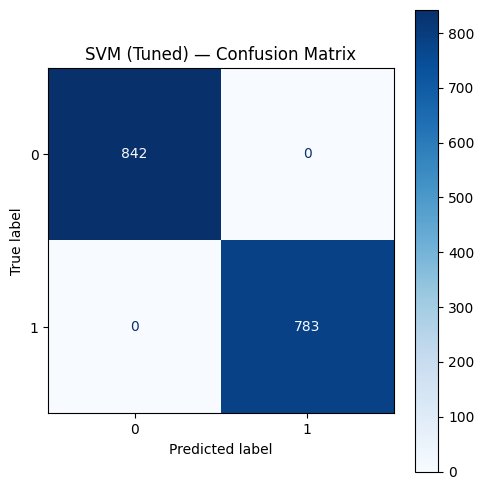

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap='Blues')
ax.set_title('SVM (Tuned) — Confusion Matrix')
plt.tight_layout()
plt.savefig(f'{VIZ}/svm_confusion_matrix.png', dpi=150)
plt.show()

Predictions on the unseen test set — actual vs predicted (`decision_score` > 0 means the SVM predicts poisonous):

In [8]:
labels = {0: 'Edible', 1: 'Poisonous'}
predictions = pd.DataFrame({
    'actual': y_test.map(labels),
    'predicted': pd.Series(y_pred_best, index=y_test.index).map(labels),
    'decision_score': best_model.decision_function(X_test).round(4),
})
predictions['correct'] = np.where(predictions['actual'] == predictions['predicted'], 'YES', 'NO')

print("Correct:", (predictions['correct'] == 'YES').sum(), "| Wrong:", (predictions['correct'] == 'NO').sum())
predictions.to_csv(f'{OUT}/svm_test_predictions.csv')
predictions.head(10)

Correct: 1625 | Wrong: 0


,actual,predicted,decision_score,correct
4632,Poisonous,Poisonous,1.5047,YES
3444,Poisonous,Poisonous,1.8782,YES
1209,Edible,Edible,-11.1329,YES
6880,Poisonous,Poisonous,0.9997,YES
4542,Poisonous,Poisonous,3.5039,YES
244,Edible,Edible,-3.8418,YES
458,Edible,Edible,-7.4788,YES
1315,Edible,Edible,-11.1330,YES
980,Edible,Edible,-5.3121,YES
2241,Poisonous,Poisonous,1.0000,YES


## 7. Compare Baseline vs. Tuned

In [9]:
comparison = pd.DataFrame({
    'Model': ['Baseline (default RBF)', 'Tuned (GridSearchCV)'],
    'Accuracy': [baseline_acc, best_acc],
    'Precision': [baseline_prec, best_prec],
    'Recall': [baseline_rec, best_rec],
    'F1': [baseline_f1, best_f1],
})
comparison

,Model,Accuracy,Precision,Recall,F1
0,Baseline (default RBF),1.0,1.0,1.0,1.0
1,Tuned (GridSearchCV),1.0,1.0,1.0,1.0


**Observation:** *(write your own numbers after running)* compare the baseline and tuned rows above and state the best parameters selected by `GridSearchCV` (`grid_search.best_params_`) together with the confusion-matrix counts.

The Mushroom dataset is known to be (near-)perfectly separable by a small number of categorical features, so it is normal for the default RBF baseline and the tuned SVM to score almost the same, or even identically, on the held-out test set. That is a property of the data rather than a sign the tuning was pointless: `GridSearchCV` shows which kernel and `C` reach that performance and confirms it is stable under cross-validation, and a tuned model with a sensible `C` is expected to generalise more reliably than the default on data that is not as cleanly separable.

## 8. Feature Importance

An SVM with a non-linear kernel has no built-in feature importances, so **permutation importance** is used: each bit-column is shuffled on the test set and the drop in F1 is measured. Because Binary Encoding splits every original feature into several bit-columns (e.g. `odor_0 … odor_3`), the importances are **summed per original feature**.

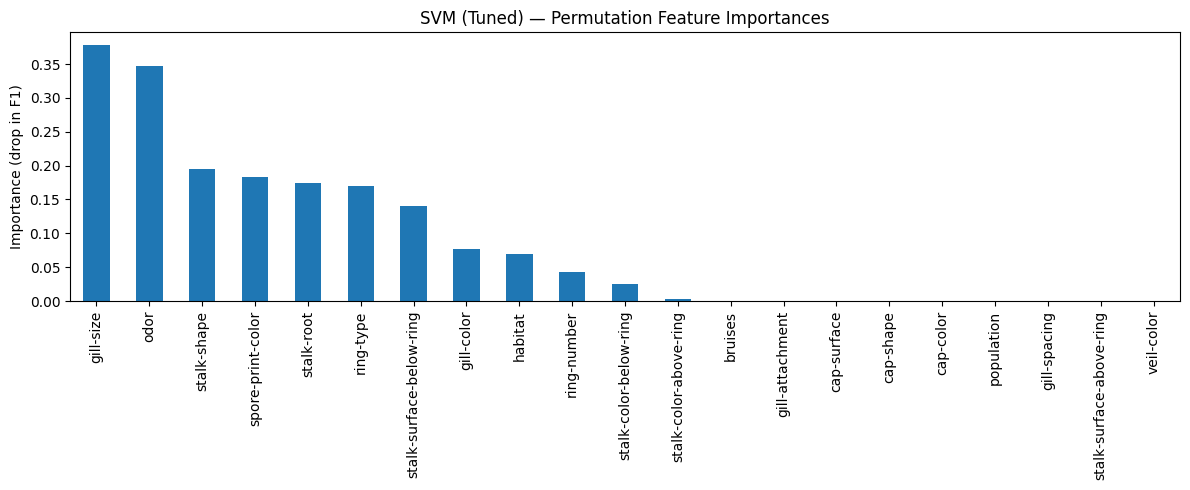

,0
gill-size,0.377948
odor,0.347641
stalk-shape,0.194785
spore-print-color,0.182807
stalk-root,0.174683
ring-type,0.169270
stalk-surface-below-ring,0.140448
gill-color,0.076510
habitat,0.069391
ring-number,0.042543


In [10]:
perm = permutation_importance(best_model, X_test, y_test, scoring='f1',
                              n_repeats=5, random_state=42, n_jobs=-1)
bit_importance = pd.Series(perm.importances_mean, index=X.columns)

# bit-column 'odor_2' -> original feature 'odor'
original_feature = [c.rsplit('_', 1)[0] for c in X.columns]
importances = bit_importance.groupby(original_feature).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind='bar')
plt.ylabel('Importance (drop in F1)')
plt.title('SVM (Tuned) — Permutation Feature Importances')
plt.tight_layout()
plt.savefig(f'{VIZ}/svm_feature_importance.png', dpi=150)
plt.show()

importances

**Comment:** *(write your own after running)* note which original features rank highest. Several features in this dataset are highly correlated with edibility and with each other, so shuffling a single feature may barely hurt the score because the others still carry the same signal — importances can therefore be small or spread out even for features that are strongly predictive on their own. If the test score is already ~100 %, most values will be close to 0.

## 9. Limitations and Possible Improvements

**Limitations:**
- SVM kernels are hard to interpret: unlike a decision tree there is no human-readable rule, and
  Binary Encoding makes it harder still because each original feature is spread over several
  bit-columns that do not map to single categories.
- SVM does not give calibrated probabilities by default (only a signed distance to the decision
  boundary), which matters when the cost of a false negative (poisonous predicted edible) is high.
- The mode imputation and the Binary Encoder were fitted on the full dataset in
  `IT0004_BinaryEncoding.ipynb` before the train/test split. Both are unsupervised and the
  `stalk-root` mode is very stable, so the effect is negligible, but strictly it is not a
  leakage-free pipeline.

**Possible improvements:**
- **Probability calibration** (`CalibratedClassifierCV`) so the model outputs usable probabilities.
- **Cost-sensitive learning** (`class_weight`) that penalises false negatives more than false
  positives.
- Fitting the imputer and Binary Encoder **inside a `Pipeline`** so they are fitted on training
  folds only.
- Trying the same SVM on a **different member's encoded output** (e.g. the one-hot or Chi-Square
  selected features) to see how the encoding affects SVM performance and training time.

## 10. Save the Final Model and Results

In [11]:
import joblib

joblib.dump(best_model, f'{OUT}/svm_best_model.pkl')

results_summary = pd.DataFrame({
    'Model': ['Baseline (default RBF)', 'Tuned (GridSearchCV)'],
    'Accuracy': [baseline_acc, best_acc],
    'Precision': [baseline_prec, best_prec],
    'Recall': [baseline_rec, best_rec],
    'F1': [baseline_f1, best_f1],
})
results_summary.to_csv(f'{OUT}/svm_results_summary.csv', index=False)
results_summary

,Model,Accuracy,Precision,Recall,F1
0,Baseline (default RBF),1.0,1.0,1.0,1.0
1,Tuned (GridSearchCV),1.0,1.0,1.0,1.0
